In [1]:
import sys
import os

# Add the src directory to sys.path
sys.path.append(os.path.abspath("../src"))

In [33]:
from collections import defaultdict

import matplotlib.pyplot as plt
import numpy as np
import torch
from torch import nn, Tensor
from torch.optim import AdamW
from torch.utils.data import DataLoader, TensorDataset

from abstractions.dsl.abstraction import Abstraction
from abstractions.dsl.instantiation import instantiate
from abstractions.dsl.core import Shape, print_tree
from abstractions.dsl.nodes import Rect, Move, SymTrans, SymRef, Union
from abstractions.learning.utils import add, get_singletons, get_pairs

from abstractions.primitives.visualization import show_boxes
from abstractions.data.generator import generate_dataset
from abstractions.learning.abstraction_discovery import find_abstractions, integrate_abstractions

import ipywidgets as widgets
import pandas as pd
import plotly.express as px
from IPython.display import display

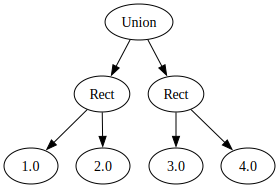

In [5]:
type_list = [Union, Rect, float, float, Rect, float, float]
param_list = [1, 2, 3, 4]
shape = instantiate(type_list, param_list)

print_tree(shape)

In [6]:
show_boxes(shape.get_box_list())

Output()

In [7]:
# Generate one table shape using the new generator interface
table = generate_dataset("table_1", 1)[0]

# Print the DSL tree nicely using the new print_tree function
print_tree(table)

# Visualize the evaluated boxes interactively
show_boxes(table.get_box_list())

Output()

In [8]:
dataset = (
    generate_dataset("chair_1", 512) +
    generate_dataset("chair_2", 512) +
    generate_dataset("table_1", 512)
)

In [11]:
singletons = get_singletons(dataset)
pairs = get_pairs(dataset)
structures = add(singletons, pairs)

In [20]:
for key, instances in structures.items():
    print(f"Structure: {key} | Count: {len(instances)} | Sample Params: {instances[4]}")

Structure: Rect | Count: 4608 | Sample Params: (0.7, 0.1)
Structure: Move | Count: 3072 | Sample Params: (<abstractions.dsl.nodes.Rect object at 0x11fbced80>, 0.425, -0.35)
Structure: SymRef | Count: 1024 | Sample Params: (<abstractions.dsl.nodes.Move object at 0x11fbcf0b0>, 'x')
Structure: Union | Count: 3072 | Sample Params: (<abstractions.dsl.nodes.Move object at 0x11fbcee40>, <abstractions.dsl.nodes.Rect object at 0x11fbcee70>)
Structure: Union(Move, Rect) | Count: 1024 | Sample Params: (<abstractions.dsl.nodes.Rect object at 0x11fbcf110>, -0.3, 0.42500000000000004, 0.65, 0.07500000000000001)
Structure: Union(Union, SymRef) | Count: 512 | Sample Params: (<abstractions.dsl.nodes.Move object at 0x11fbcf140>, <abstractions.dsl.nodes.Rect object at 0x11fbcf170>, <abstractions.dsl.nodes.Move object at 0x11fbcf0b0>, 'x')
Structure: Union(Move, Move) | Count: 512 | Sample Params: (<abstractions.dsl.nodes.Rect object at 0x11fcc1550>, 0.0, -0.4125, <abstractions.dsl.nodes.Rect object at 0x1

In [26]:
# Your global structures dict is assumed
# Convert dict entry to DataFrame
def make_df_for_structure(name):
    data = structures[name]
    df = pd.DataFrame(data)
    df.columns = [f"param_{i}" for i in range(df.shape[1])]
    return df

# Dropdown to select structure
structure_names = list(structures.keys())
dropdown = widgets.Dropdown(options=structure_names, description='Structure:')

# Output widget for displaying both table and plot
output = widgets.Output()

def on_change(change):
    if change['type'] == 'change' and change['name'] == 'value':
        structure_name = change['new']
        df = make_df_for_structure(structure_name)
        output.clear_output()

        with output:
            print(f"Structure: {structure_name}")
            display(df.head(20))

            if df.shape[1] >= 2:
                fig = px.scatter(
                    df, x='param_0', y='param_1',
                    title=f"Scatter plot of {structure_name}",
                    hover_data=df.columns
                )
                fig.show()
            else:
                print("Structure has fewer than 2 parameters — cannot plot.")

# Hook up the dropdown to the function
dropdown.observe(on_change)

# Display everything
# display(dropdown, output)

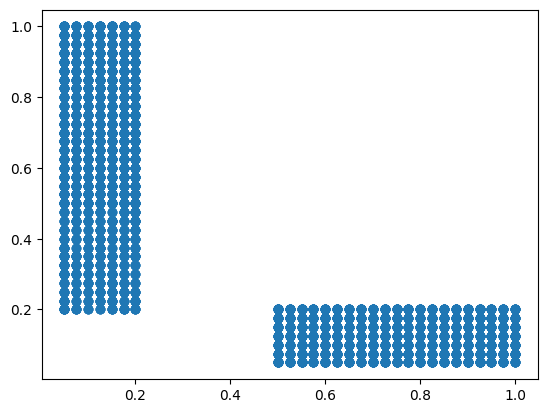

In [24]:

plt.figure()
plt.scatter([s[0] for s in structures["Rect"]], [s[1] for s in structures["Rect"]])
plt.show()


In [28]:
models, losses = find_abstractions(structures, retrain_iterations=4, error_threshold=0.01)

Iteration 1/4: training model for Rect on 4608 structures.
Iteration 2/4: training model for Rect on 702 structures.
Iteration 3/4: training model for Rect on 665 structures.
Iteration 4/4: training model for Rect on 438 structures.
Trained model for Rect. Final train loss: 0.005042219334947211
Iteration 1/4: training model for Move on 3072 structures.
Iteration 2/4: training model for Move on 1107 structures.
Iteration 3/4: training model for Move on 1106 structures.
Iteration 4/4: training model for Move on 1115 structures.
Trained model for Move. Final train loss: 0.0021043688563319543
Iteration 1/4: training model for Union(Move, Rect) on 1024 structures.
Iteration 2/4: training model for Union(Move, Rect) on 43 structures.
Iteration 3/4: training model for Union(Move, Rect) on 1 structures.
Iteration 4/4: training model for Union(Move, Rect) on 1 structures.
Trained model for Union(Move, Rect). Final train loss: 0.018062889575958252
Iteration 1/4: training model for Union(Move, Mo

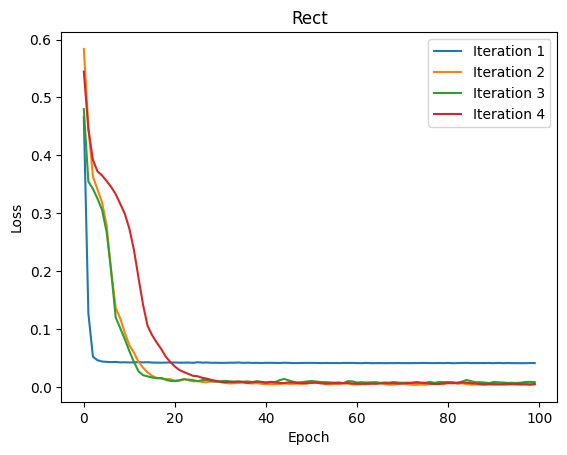

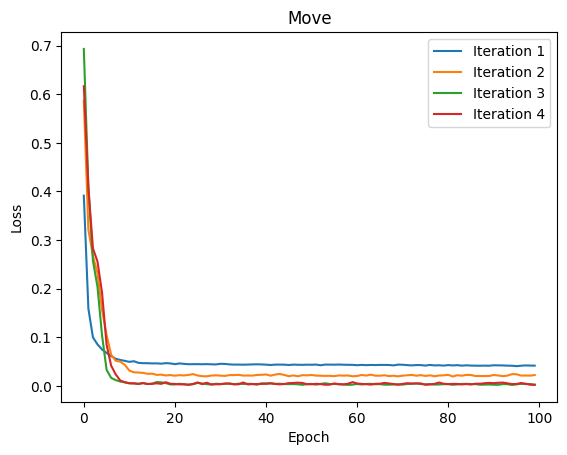

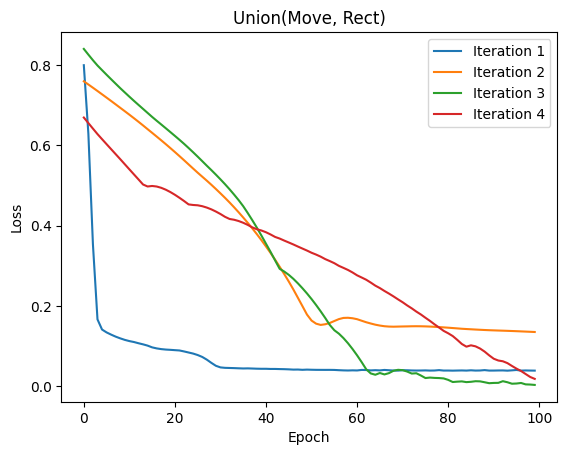

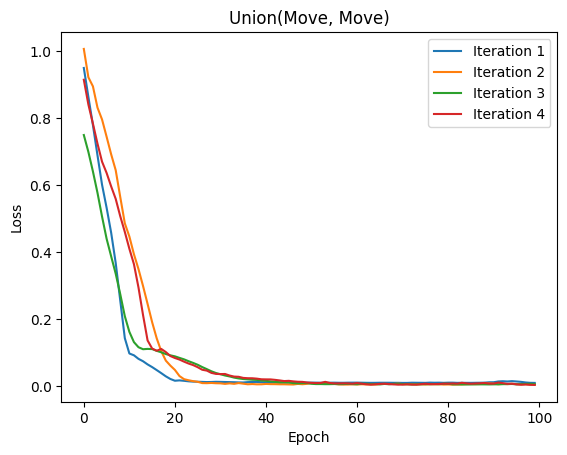

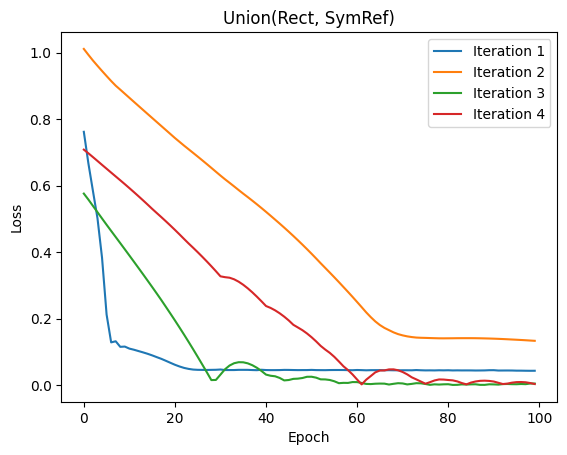

In [29]:

for structure_name, loss_list in losses.items():
    plt.figure()

    for i in range(len(loss_list)):
        plt.plot(loss_list[i], label=f"Iteration {i+1}")

    plt.legend()
    plt.title(structure_name)
    plt.xlabel("Epoch")
    plt.ylabel("Loss")

plt.show()


In [31]:
import ipywidgets as widgets
import plotly.graph_objects as go
from IPython.display import display

# Dropdown for selecting structure
structure_dropdown = widgets.Dropdown(
    options=list(losses.keys()),
    description="Structure:",
    layout=widgets.Layout(width='50%')
)

# Output area for interactive plot
output = widgets.Output()

# Function to update plot
def plot_loss_curve(structure_name):
    fig = go.Figure()
    for i, loss_curve in enumerate(losses[structure_name]):
        fig.add_trace(go.Scatter(
            y=loss_curve,
            mode='lines',
            name=f'Retrain {i+1}'
        ))
    fig.update_layout(
        title=f"Loss Curve for {structure_name}",
        xaxis_title="Epoch",
        yaxis_title="Loss",
        height=400,
        width=700
    )
    return fig

# Event listener for dropdown change
def on_dropdown_change(change):
    if change['type'] == 'change' and change['name'] == 'value':
        output.clear_output()
        with output:
            fig = plot_loss_curve(change['new'])
            fig.show()

# Hook up dropdown to function
structure_dropdown.observe(on_dropdown_change)

# Display UI
display(structure_dropdown, output)

# Trigger once to show default
output.clear_output()
with output:
    fig = plot_loss_curve(structure_dropdown.value)
    fig.show()

Dropdown(description='Structure:', layout=Layout(width='50%'), options=('Rect', 'Move', 'Union(Move, Rect)', '…

Output()

In [32]:
threshold = 0.01  # error threshold
structure_dropdown = widgets.Dropdown(options=list(models.keys()), description="Structure:")
output = widgets.Output()

def compute_projection_and_error(structure_name):
    model = models[structure_name]
    parameters = structures[structure_name]

    valid_indices = [i for i, val in enumerate(parameters[0]) if isinstance(val, float)]
    if not valid_indices:
        return None

    float_params = [[p[i] for p in parameters] for i in valid_indices]
    data = torch.tensor(float_params, dtype=torch.float32).T  # shape [N, D]

    model.eval()
    with torch.no_grad():
        enc, recon = model(data)
        error = torch.max(torch.abs(recon - data), dim=-1)[0]
        well_explained = error < threshold

    df = pd.DataFrame(data.numpy(), columns=[f"param_{i}" for i in range(data.shape[1])])
    df["error"] = error.numpy()
    df["well_explained"] = well_explained.numpy()
    df["x"] = df.iloc[:, 0]
    df["y"] = df.iloc[:, 1] if data.shape[1] > 1 else 0.0
    return df

def update_plot(change):
    name = change["new"]
    df = compute_projection_and_error(name)
    output.clear_output()
    with output:
        if df is None:
            print("Structure has no float parameters.")
            return

        scatter = px.scatter(
            df, x="x", y="y",
            color="well_explained",
            hover_data=df.columns,
            color_discrete_map={True: "green", False: "red"},
            title=f"{name} – reconstruction quality"
        )

        error_line = px.line(
            df.sort_values("error").reset_index(),
            y="error",
            title=f"{name} – sorted reconstruction error"
        )

        scatter.show()
        error_line.show()

structure_dropdown.observe(update_plot, names='value')
display(structure_dropdown, output)

# Trigger first draw
structure_dropdown.value = structure_dropdown.options[0]

Dropdown(description='Structure:', options=('Rect', 'Move', 'Union(Move, Rect)', 'Union(Move, Move)', 'Union(R…

Output()

In [34]:
abs_dataset = integrate_abstractions(dataset, models, error_threshold=0.03)

In [35]:
abs_dataset

 ...]

In [47]:
from IPython.display import display, Markdown
index = 1
display(Markdown("### Original DSL Program"))
print(dataset[index])
#show_boxes(dataset[index].get_box_list())

### Original DSL Program

Union(
        Union(
            Move(
                Rect(
                0.050,
                0.725
            ),
            -0.325,
            0.413
        ),
            Rect(
            0.700,
            0.100
        )
    ),
        SymRef(
            Move(
                Rect(
                0.100,
                0.850
            ),
            0.300,
            -0.475
        ),
        x
    )
)


In [48]:

display(Markdown("### After Abstraction"))
print(abs_dataset[index])
#show_boxes(abs_dataset[index].get_box_list())

### After Abstraction

Union(
        Union(
            Move(
                Rect(
                0.050,
                0.725
            ),
            -0.325,
            0.413
        ),
            Rect(
            0.700,
            0.100
        )
    ),
        SymRef(
            Move(
                Rect(
                0.100,
                0.850
            ),
            0.300,
            -0.475
        ),
        x
    )
)


In [44]:
def count_nodes(shape):
    if not isinstance(shape, Shape):
        return 1
    _, args = shape.param_tuple()
    return 1 + sum(count_nodes(arg) for arg in args)

print("Original node count:", count_nodes(dataset[index]))
print("Abstracted node count:", count_nodes(abs_dataset[index]))

Original node count: 24
Abstracted node count: 16


In [50]:
from abstractions.dsl.abstraction import Abstraction

def contains_abstraction(shape):
    """
    Recursively checks whether a shape program contains an Abstraction node.
    """
    if isinstance(shape, Abstraction):
        return True
    if not isinstance(shape, Shape):
        return False
    _, args = shape.param_tuple()
    return any(contains_abstraction(arg) for arg in args)

In [51]:
abstracted_indices = [i for i, shape in enumerate(abs_dataset) if contains_abstraction(shape)]

print(f"{len(abstracted_indices)} / {len(abs_dataset)} shapes were abstracted")
print("First few abstracted indices:", abstracted_indices[:10])

550 / 1536 shapes were abstracted
First few abstracted indices: [0, 82, 512, 513, 514, 515, 516, 517, 518, 519]


In [52]:
import ipywidgets as widgets
from IPython.display import display, Markdown
import matplotlib.pyplot as plt

# Assuming contains_abstraction() and count_nodes() are defined as before

# Find indices with abstraction
abstracted_indices = [i for i, shape in enumerate(abs_dataset) if contains_abstraction(shape)]

# Prepare compression data
compression_data = []
for i in abstracted_indices:
    before = count_nodes(dataset[i])
    after = count_nodes(abs_dataset[i])
    compression_data.append((i, before, after, before - after))

# Sort by compression amount descending
compression_data.sort(key=lambda x: x[3], reverse=True)

# Dropdown widget to select index
dropdown = widgets.Dropdown(
    options=[(f"Index {i} | Δ={delta}", i) for i, _, _, delta in compression_data],
    description="Shape Index:"
)

output = widgets.Output()

def show_comparison(idx):
    output.clear_output()
    with output:
        display(Markdown(f"### Shape Index: {idx}"))
        before = dataset[idx]
        after = abs_dataset[idx]

        print("Original DSL Tree:")
        print_tree(before)

        print("\nAbstracted DSL Tree:")
        print_tree(after)

        print(f"\nNode count before: {count_nodes(before)}")
        print(f"Node count after: {count_nodes(after)}")

        # Show geometry
        fig, axs = plt.subplots(1, 2, figsize=(10, 5))
        axs[0].set_title("Original")
        show_boxes(before.get_box_list())
        axs[1].set_title("Abstracted")
        show_boxes(after.get_box_list())

        plt.show()

dropdown.observe(lambda change: show_comparison(change['new']), names='value')

display(dropdown, output)

# Trigger initial display
if compression_data:
    show_comparison(compression_data[0][0])
else:
    print("No abstracted shapes found.")

Dropdown(description='Shape Index:', options=(('Index 990 | Δ=13', 990), ('Index 512 | Δ=8', 512), ('Index 513…

Output()